# Preprocessing MIT-BIH Arrhythmia Database
### FP: Explainable Hybrid CNN-Transformer for Imbalanced ECG Arrhythmia Classification

Pipeline:
`sinyal mentah` → **Butterworth zero-phase (0.5–45 Hz)** → **segmentasi R-peak (180 sampel @ 360 Hz)** → **z-score per-detak** → **ekstraksi clinical features** → simpan array siap-latih.

**Penting:** notebook ini memakai file **WFDB mentah** (`.dat/.hea/.atr`), bukan CSV pra-proses. File diunduh otomatis dari PhysioNet pada sel di bawah.

**Anti-leakage:** z-score per-detak bersifat per-sampel (tidak ada parameter di-fit). `StandardScaler` untuk clinical features di-fit **hanya pada train**. SMOTE (tahap berikut) juga hanya pada train.

## 1. Instalasi & Import

In [ ]:
!pip install wfdb -q

wfdb: library standar untuk membaca database PhysioNet/rekaman medis

In [ ]:
import os
import numpy as np
import wfdb
from scipy.signal import butter, filtfilt, welch, resample_poly
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter


print("wfdb", wfdb.__version__)

wfdb 4.3.1


## 2. Unduh dataset mentah dari PhysioNet
`wfdb.dl_database('mitdb', ...)` mengunduh seluruh 48 rekaman (~104 MB) langsung ke sesi Colab. Cukup dijalankan sekali; jika folder sudah ada, sel ini akan melewati unduhan.

In [ ]:
DATA_DIR = "mitdb"   # folder tujuan unduhan

if not os.path.isdir(DATA_DIR) or not any(f.endswith(".dat") for f in os.listdir(DATA_DIR) if os.path.isfile(os.path.join(DATA_DIR, f))):
    wfdb.dl_database('mitdb', dl_dir=DATA_DIR)
    print("Selesai mengunduh.")
else:
    print("Folder sudah berisi data, lewati unduhan.")

print("Contoh isi folder:", sorted(os.listdir(DATA_DIR))[:9])

Folder sudah berisi data, lewati unduhan.
Contoh isi folder: ['100.atr', '100.dat', '100.hea', '101.atr', '101.dat', '101.hea', '102.atr', '102.dat', '102.hea']


## 3. Konfigurasi

In [ ]:
class Config:
    DATA_DIR    = 'mitdb'
    OUTPUT_DIR  = 'processed'
    FS          = 360
    LOWCUT      = 0.5
    HIGHCUT     = 45.0
    FILTER_ORDER = 3
    WINDOW      = 180          # ~0.5 detik @ 360 Hz
    LEFT        = 90
    RIGHT       = 90
    MS_KERNELS  = (5, 15)      # ukuran kernel multi-scale
    SMOTE_SEED  = 42

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

Frekuensi: Di bawah 0.5Hz biasanya noise orang bernapas, di atas 45Hz noise listrik statis.

## 4. Pemetaan anotasi → 5 kelas AAMI & pembagian inter-patient
Pembagian **DS1/DS2 (de Chazal dkk., 2004)** = *patient-wise*: seluruh detak satu pasien hanya masuk train ATAU test, tidak pernah keduanya. 4 rekaman paced (102, 104, 107, 217) dibuang sesuai rekomendasi AAMI.

4 rekaman dimasukkan, patient wise artinya dibagi berdassrkan pasien karena ecg tiap pasien ada khas masing2. kelas Q di de Chazal dibuang krna pasien menggunakan alat pacu jantung yg memberikan spike2 sehingga sangat mudah dikenali (dianggap tdk menantang).

de Chazal, P., O'Dwyer, M. & Reilly, R.B. (2004). "Automatic classification of heartbeats using ECG morphology and heartbeat interval features." IEEE Transactions on Biomedical Engineering, 51(7), 1196–1206. DOI: 10.1109/TBME.2004.827359

pertama kali merumuskan protokol evaluasi inter-patient untuk MIT-BIH yang kemudian jadi standar de facto sampai hari ini.

- mereka mengusulkan pemetaan 5 kelas AAMI sesuai standar ANSI/AAMI EC57:1998.
- mereka yang menetapkan praktik membuang 4 rekaman paced. Data diambil dari 44 rekaman non-pacemaker MIT-BIH Arrhythmia Database — 4 rekaman paced (102, 104, 107, 217) sengaja dibuang,
- mereka yang membuat pembagian DS1/DS2. Data dibagi menjadi dua dataset, masing-masing berisi sekitar 50.000 detak dari 22 rekaman (sesuai codingan).

Jika memutuskan benar-benar memasukkan kembali 4 rekaman paced (jalur 5 kelas penuh), maka protokol bukan lagi de Chazal murni — itu adaptasi. Itu sah, tapi di laporan sebaiknya Anda tulis terus terang, misal: "Kami mengikuti protokol patient-wise gaya de Chazal dkk. (2004), namun mempertahankan 4 rekaman paced agar 5 kelas AAMI lengkap, berbeda dari versi original yang membuangnya."


In [ ]:
AAMI_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',     # N - Normal
    'A':'S','a':'S','J':'S','S':'S',             # S - Supraventricular ectopic
    'V':'V','E':'V',                             # V - Ventricular ectopic
    'F':'F',                                     # F - Fusion
    '/':'Q','f':'Q','Q':'Q',                     # Q - Unknown / paced
}
CLASSES = ['N','S','V','F','Q']
LABEL2IDX = {c:i for i,c in enumerate(CLASSES)}

DS1_TRAIN = [101,106,108,109,112,114,115,116,118,119,122,124,
             201,203,205,207,208,209,215,220,223,230, 102, 107]
DS2_TEST  = [100,103,105,111,113,117,121,123,200,202,210,212,
             213,214,219,221,222,228,231,232,233,234, 104, 217]
print("Train:", len(DS1_TRAIN), "rekaman | Test:", len(DS2_TEST), "rekaman")

Train: 24 rekaman | Test: 24 rekaman


Standar AAMI (Association for the Advancement of Medical Instrumentation).

Di dalam dataset asli MIT-BIH, para dokter kardiologi memberikan lebih dari 15 jenis simbol anotasi yang sangat spesifik untuk setiap detak (misalnya 'N', 'L', 'R', 'V', '/', 'A', dll). Namun, untuk keperluan evaluasi Machine Learning, 15+ label tersebut biasanya dikelompokkan menjadi 5 super-kelas saja.

**Kelas N (Normal)**

Ini adalah kelompok detak jantung yang dianggap normal atau variasi blok cabang yang secara klinis sering dikelompokkan bersama detak normal dalam eksperimen ini.

- 'N': Normal beat.
- 'L': Left bundle branch block beat.
- 'R': Right bundle branch block beat.
- 'e': Atrial escape beat.
- 'j': Nodal (junctional) escape beat.


**Kelas S (Supraventricular Ectopic)**

Kelompok detak prematur (ektopik) yang sumber masalahnya berasal dari bagian atas jantung (atrium), di atas bilik ventrikel.

- 'A': Atrial premature beat.
- 'a': Aberrated atrial premature beat.
- 'J': Nodal (junctional) premature beat.
- 'S': Supraventricular premature beat.

**Kelas V (Ventricular Ectopic)**

Kelompok detak prematur yang sumber masalahnya berasal dari bilik jantung bawah (ventrikel). Ini adalah salah satu aritmia yang paling berbahaya dan paling sering dideteksi oleh AI.

- 'V': Premature ventricular contraction (PVC).
- 'E': Ventricular escape beat.

**Kelas F (Fusion)**

Kelompok detak hibrida atau "fusi". Ini terjadi ketika detak normal dan detak ventrikel prematur (PVC) terjadi di saat yang bersamaan, sehingga bentuk gelombangnya merupakan perpaduan dari keduanya.

- 'F': Fusion of ventricular and normal beat.

**Kelas Q (Unknown / Paced)**

Kelompok detak yang tidak diketahui, tidak dapat diklasifikasikan, atau berasal dari rangsangan alat pacu jantung buatan (pacemaker).

- '/': Paced beat (detak buatan dari alat pacu jantung).
- 'f': Fusion of paced and normal beat.
- 'Q': Unclassifiable beat.

## 5. Fungsi DSP inti

In [ ]:
def bandpass_filter(signal, fs, lowcut, highcut, order):
    """Butterworth bandpass ZERO-PHASE (filtfilt: maju-mundur, tanpa geser fasa).
    Menekan baseline wander (<0.5 Hz) & noise HF (>45 Hz), morfologi P-QRS-T terjaga."""
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')

    return filtfilt(b, a, signal)


def resample_to_360(signal, fs_in, fs_out=360):
    """Resample ke 360 Hz (untuk Icentia11k 250 Hz). MIT-BIH sudah 360 -> dilewati."""
    if fs_in == fs_out:
        return signal

    from math import gcd
    g = gcd(int(fs_out), int(fs_in))

    return resample_poly(signal, int(fs_out)//g, int(fs_in)//g)

# Z-score: Menormalisasi amplitudo masing-masing jendela potongan detak EKG agar ukurannya seragam tanpa merusak bentuk morfologinya
def zscore_per_beat(beat):
    """z-score per-detak (mean=0, std=1). Per-sampel -> tidak ada leakage."""
    mu, sd = beat.mean(), beat.std()

    return (beat - mu) / sd if sd > 1e-8 else beat - mu

## 6. Ekstraksi fitur
**Clinical features** (13): statistik, energi, ZCR, spektral.
**Multi-scale features** (kernel 5 & 15): smoothing Gaussian dengan dua ukuran kernel -> 3 channel per detak (asli + smoothed scale-5 + smoothed scale-15). Kernel kecil menangkap detail QRS sempit; kernel besar menangkap konteks P-T yang lebih lebar.

In [ ]:
# Menghitung 13 ciri klinis tambahan (seperti statistik, energi, rasio zero-crossing) dari sinyal yang belum di-Z-score.
CLINICAL_FEATURE_NAMES = [
    'mean','std','rms','skew','kurtosis','ptp',          # statistik (6)
    'energy',                                            # energi (1)
    'zcr',                                               # zero-crossing rate (1)
    'spec_centroid','spec_entropy','dom_freq',
    'total_power','spec_spread',                         # spektral (5)
]

def extract_clinical_features(beat, fs):
    """13 clinical features dari detak TERFILTER (sebelum z-score)."""
    feats = []
    # statistik
    feats += [np.mean(beat), np.std(beat), np.sqrt(np.mean(beat**2)),
              skew(beat), kurtosis(beat), np.ptp(beat)]

    # energi
    feats.append(np.sum(beat**2))

    # ZCR
    feats.append(np.sum(np.abs(np.diff(np.sign(beat))) > 0) / len(beat))

    # spektral (Welch PSD)
    f, pxx = welch(beat, fs=fs, nperseg=min(128, len(beat)))
    pxx_n = pxx / (pxx.sum() + 1e-12)
    centroid = np.sum(f * pxx_n)
    entropy  = -np.sum(pxx_n * np.log2(pxx_n + 1e-12))
    dom_freq = f[np.argmax(pxx)]
    total_p  = np.sum(pxx)
    spread   = np.sqrt(np.sum(((f - centroid)**2) * pxx_n))
    feats += [centroid, entropy, dom_freq, total_p, spread]

    return np.asarray(feats, dtype=np.float32)

In [ ]:
def gaussian_kernel(size, sigma=None):
    """Kernel Gaussian dinormalisasi (jumlah=1)."""
    if sigma is None:
        sigma = size / 6.0
    x = np.arange(size) - size // 2
    k = np.exp(-(x**2) / (2 * sigma**2))
    return (k / k.sum()).astype(np.float32)


def multi_scale_features(beat, kernel_sizes=(5, 15)):
    """Beat (180,) -> (180, 1+len(kernel_sizes)) multi-channel representation.

    Channel 0: beat asli (z-scored)
    Channel 1: smoothed dengan kernel Gaussian ukuran 5  (skala halus)
    Channel 2: smoothed dengan kernel Gaussian ukuran 15 (skala kasar)
    """
    channels = [beat.astype(np.float32)]
    for k in kernel_sizes:
        kernel = gaussian_kernel(k)
        smoothed = np.convolve(beat, kernel, mode='same').astype(np.float32)
        channels.append(smoothed)
    return np.stack(channels, axis=-1)        # (180, 3)

## 7. Pemuatan & segmentasi per rekaman

In [ ]:
def load_record(record_id, data_dir):
    """Muat satu rekaman WFDB; pilih lead MLII bila ada, jika tidak lead 0."""
    path = os.path.join(data_dir, str(record_id))
    rec = wfdb.rdrecord(path)
    ann = wfdb.rdann(path, 'atr')
    ch = rec.sig_name.index('MLII') if 'MLII' in rec.sig_name else 0
    return rec.p_signal[:, ch], ann, rec.fs, rec.sig_name[ch]


def process_record(record_id, cfg):
    """Pipeline satu rekaman -> beats(N,180), feats(N,13), labels(N,), groups(N,)."""
    signal, ann, fs, lead = load_record(record_id, cfg.DATA_DIR)
    filtered = bandpass_filter(signal, cfg.FS, cfg.LOWCUT, cfg.HIGHCUT, cfg.FILTER_ORDER)

    beats, feats, labels = [], [], []
    for peak, sym in zip(ann.sample, ann.symbol):
        cls = AAMI_MAP.get(sym)
        if cls is None:
            continue
        s, e = peak - cfg.LEFT, peak + cfg.RIGHT
        if s < 0 or e > len(filtered):
            continue
        seg = filtered[s:e]
        feats.append(extract_clinical_features(seg, cfg.FS))
        beats.append(zscore_per_beat(seg))
        labels.append(LABEL2IDX[cls])

    if not beats:
        return (np.empty((0, cfg.WINDOW)), np.empty((0, len(CLINICAL_FEATURE_NAMES))),
                np.empty((0,), int), np.empty((0,), int))
    return (np.asarray(beats, np.float32), np.asarray(feats, np.float32),
            np.asarray(labels, np.int64), np.full(len(labels), record_id, np.int64))


def build_dataset(record_ids, cfg, name=''):
    B, F, Y, G = [], [], [], []
    for rid in record_ids:
        b, f, y, g = process_record(rid, cfg)
        if len(b) == 0:
            print(f'  [!] Rekaman {rid}: 0 detak valid'); continue
        B.append(b); F.append(f); Y.append(y); G.append(g)
    X = np.concatenate(B); Xf = np.concatenate(F)
    y = np.concatenate(Y); g = np.concatenate(G)
    dist = {CLASSES[i]: int((y==i).sum()) for i in range(len(CLASSES))}
    print(f'{name}: {len(y)} detak | distribusi {dist}')
    return X, Xf, y, g

## 8. Bangun dataset (inter-patient DS1/DS2)

- X = Matriks sinyal bentuk gelombangnya.
- Xf = Matriks fitur angka-angka klinisnya.
- y = Label kelas detaknya (Normal, PVC, dll).
- g = Label identitas pasiennya.

Variabel g (g_train dan g_test) adalah singkatan dari Groups (atau Grup / ID Pasien).

Isi dari array g ini adalah nomor ID rekaman pasien (misalnya 101, 106, 201, dst.) untuk setiap potong detak jantung yang ada di X_train maupun X_test.

Artinya, jika 5 detak jantung pertama di matriks X_train berasal dari pasien nomor 101, maka 5 nilai pertama di dalam g_train adalah [101, 101, 101, 101, 101].

Mengapa variabel g ini penting untuk disimpan?
- Pelacakan (Tracking): Meskipun kita sudah memotong-motong sinyal menjadi puluhan ribu detak individu, kita tetap tidak kehilangan jejak. Kita tahu persis detak pada baris ke-9.999 itu milik pasien yang mana.

- Mencegah Kebocoran Data saat Validasi (GroupKFold): Saat Anda melatih model AI nanti, Anda pasti perlu membagi X_train menjadi data Train dan data Validation (untuk melihat performa model tiap epoch). Anda wajib membaginya berdasarkan pasien (pasien di train tidak boleh ada di validation). Variabel g_train inilah yang nantinya dimasukkan ke fungsi seperti GroupKFold di scikit-learn sebagai pemandunya.

- Analisis Error: Jika model AI Anda sering salah menebak kelas pada saat pengujian (testing), Anda bisa menggunakan g_test untuk mencari tahu: "Model ini gagalnya kebanyakan di detak miliknya pasien nomor berapa sih?"

In [ ]:
print('=== TRAIN (DS1) ===')
X_train, Xf_train, y_train, g_train = build_dataset(DS1_TRAIN, cfg, 'TRAIN')
print('\n=== TEST (DS2) ===')

X_test,  Xf_test,  y_test,  g_test  = build_dataset(DS2_TEST, cfg, 'TEST')
print(f'\nBeats train: {X_train.shape} | test: {X_test.shape}')
print(f'Clinical train: {Xf_train.shape} | test: {Xf_test.shape}')

=== TRAIN (DS1) ===
TRAIN: 55334 detak | distribusi {'N': 45955, 'S': 944, 'V': 3851, 'F': 414, 'Q': 4170}

=== TEST (DS2) ===
TEST: 54134 detak | distribusi {'N': 44653, 'S': 1837, 'V': 3384, 'F': 388, 'Q': 3872}

Beats train: (55334, 180) | test: (54134, 180)
Clinical train: (55334, 13) | test: (54134, 13)


## 9. SMOTE — hanya pada training
**Strategi:**
1. Gabung `[beats | clinical]` jadi vektor flat (193 fitur per sampel).
2. SMOTE oversample semua kelas minoritas ke jumlah kelas mayoritas (N).
3. Pisah kembali jadi beats dan clinical.
4. Multi-scale features dihitung **ulang** dari beat hasil SMOTE (lihat sel berikutnya).

**Catatan jujur:** SMOTE interpolasi linear antara sampel di ruang fitur — detak sintetisnya tidak selalu fisiologis 100%. Ini limitasi yang umum diketahui di literatur.

In [ ]:
import os
import numpy as np
import wfdb
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
before = Counter(y_train)
print('Sebelum SMOTE:', {CLASSES[k]: v for k, v in sorted(before.items())})

min_count = min(before.values())
if min_count < 2:
    raise RuntimeError(f'Ada kelas dengan <2 sampel ({min_count}). '
                       'SMOTE tidak bisa dijalankan. Cek apakah paced sudah masuk DS1.')
k_neighbors = min(5, min_count - 1)
print(f'k_neighbors aman: {k_neighbors}')

X_flat = np.concatenate([X_train, Xf_train], axis=1)        # (N, 180+13)
smote = SMOTE(k_neighbors=k_neighbors, random_state=cfg.SMOTE_SEED)
X_flat_resampled, y_train_resampled = smote.fit_resample(X_flat, y_train)

X_train_resampled  = X_flat_resampled[:, :cfg.WINDOW].astype(np.float32)
Xf_train_resampled = X_flat_resampled[:, cfg.WINDOW:].astype(np.float32)

after = Counter(y_train_resampled)
print('Sesudah SMOTE:', {CLASSES[k]: v for k, v in sorted(after.items())})
print(f'Train: {len(y_train)} -> {len(y_train_resampled)} detak')

Sebelum SMOTE: {'N': 45955, 'S': 944, 'V': 3851, 'F': 414, 'Q': 4170}
k_neighbors aman: 5
Sesudah SMOTE: {'N': 45955, 'S': 45955, 'V': 45955, 'F': 45955, 'Q': 45955}
Train: 55334 -> 229775 detak


## 10. Multi-scale features — hitung dari beat (hasil SMOTE untuk train, asli untuk test)

In [ ]:
# train: hitung dari beat resampled supaya multi-scale konsisten dengan beat-nya
X_train_multi = np.stack([multi_scale_features(b, cfg.MS_KERNELS)
                          for b in X_train_resampled])
# test: hitung dari beat asli (tidak di-SMOTE)
X_test_multi  = np.stack([multi_scale_features(b, cfg.MS_KERNELS)
                          for b in X_test])

print(f'Train multi-scale: {X_train_multi.shape}  (N, 180, 3)')
print(f'Test  multi-scale: {X_test_multi.shape}')
print(f'Kanal: 0=asli z-scored | 1=smoothed k={cfg.MS_KERNELS[0]} | 2=smoothed k={cfg.MS_KERNELS[1]}')

Train multi-scale: (229775, 180, 3)  (N, 180, 3)
Test  multi-scale: (54134, 180, 3)
Kanal: 0=asli z-scored | 1=smoothed k=5 | 2=smoothed k=15


## 11. StandardScaler clinical features — fit **hanya pada train**
Inilah titik anti-leakage utama: scaler belajar mean/varians dari train saja, lalu diterapkan apa adanya ke test.

In [ ]:
# Fitur klinis punya rentang nilai berbeda2 maka perlu distandardisasi
# Fit di Xf_train lalu transform di Xf_test untuk menghindari data leakage

scaler = StandardScaler().fit(Xf_train_resampled)
Xf_train_scaled = scaler.transform(Xf_train_resampled).astype(np.float32)
Xf_test_scaled  = scaler.transform(Xf_test).astype(np.float32)

print(f'Clinical train: {Xf_train_scaled.shape} | mean~0: {np.allclose(Xf_train_scaled.mean(0), 0, atol=1e-5)}')
print(f'Clinical test : {Xf_test_scaled.shape}')

Clinical train: (229775, 13) | mean~0: False
Clinical test : (54134, 13)


## 12. Ringkasan & simpan

In [ ]:
out_path = os.path.join(cfg.OUTPUT_DIR, 'mitbih_ready.npz')
np.savez_compressed(
    out_path,

    # train (post-SMOTE)
    X_train=X_train_multi,            # (N', 180, 3)
    Xfeat_train=Xf_train_scaled,      # (N', 13)
    y_train=y_train_resampled,        # (N',)

    # test (asli, tidak di-SMOTE)
    X_test=X_test_multi,              # (M, 180, 3)
    Xfeat_test=Xf_test_scaled,        # (M, 13)
    y_test=y_test,                    # (M,)
    groups_test=g_test,               # (M,) untuk analisis per-pasien

    # metadata
    classes=np.array(CLASSES),
    feature_names=np.array(CLINICAL_FEATURE_NAMES),
    ms_kernels=np.array(cfg.MS_KERNELS),
)
print('Tersimpan ->', out_path)
print(f'Ukuran file: {os.path.getsize(out_path)/1e6:.1f} MB')

Tersimpan -> processed/mitbih_ready.npz
Ukuran file: 580.5 MB


## 13. (Opsional) Sanity-check visual: sebelum vs sesudah filter

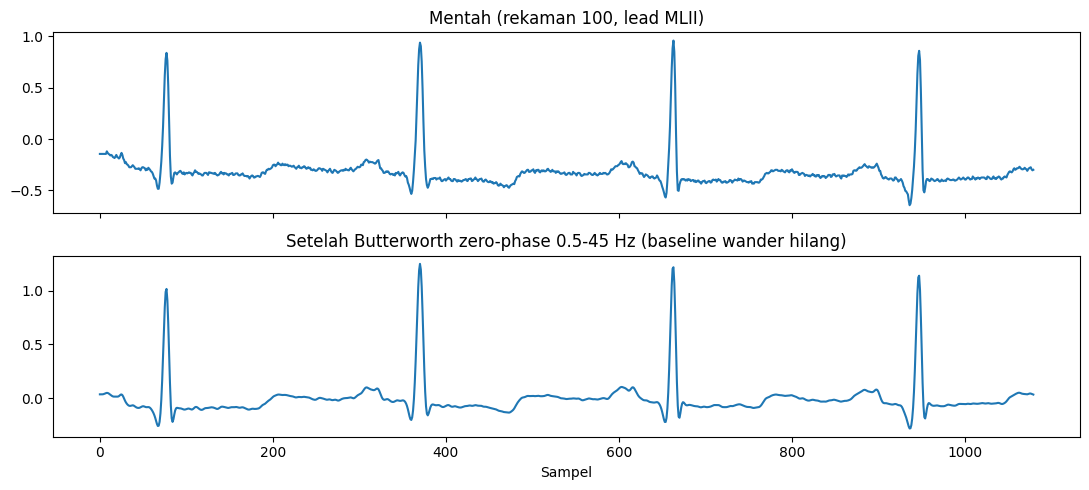

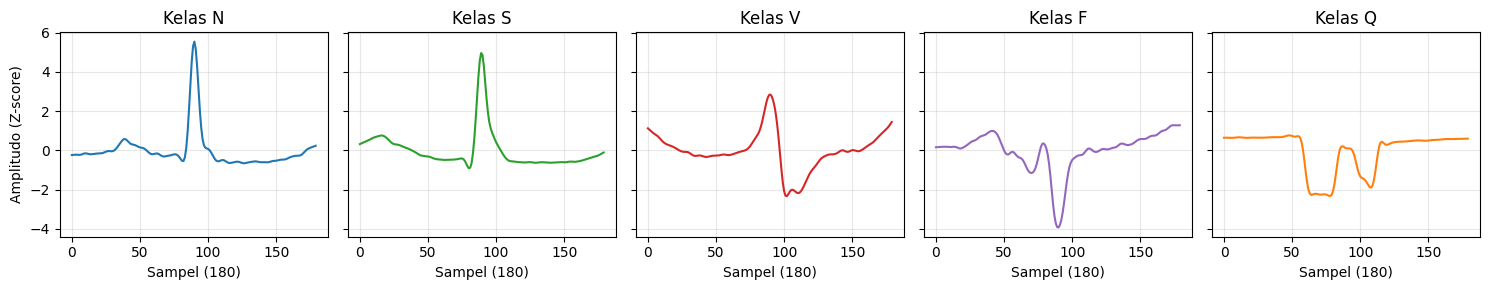

In [ ]:
# 1. Sudut Pandang Makro: 3 detik pertama sinyal mentah vs filter
sig, ann, fs, lead = load_record(DS2_TEST[0], cfg.DATA_DIR)
filt = bandpass_filter(sig, cfg.FS, cfg.LOWCUT, cfg.HIGHCUT, cfg.FILTER_ORDER)
n = cfg.FS * 3   # tampilkan 3 detik pertama

fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(sig[:n]);  ax[0].set_title(f"Mentah (rekaman {DS2_TEST[0]}, lead {lead})")
ax[1].plot(filt[:n]); ax[1].set_title("Setelah Butterworth zero-phase 0.5-45 Hz (baseline wander hilang)")
ax[1].set_xlabel("Sampel"); plt.tight_layout(); plt.show()

# =========================================================================

# 2. Sudut Pandang Mikro: Membandingkan 5 contoh detak ter-z-score (5 Kelas)
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#ff7f0e']

# Kita looping langsung menggunakan variabel CLASSES dan y_train milik Anda
for i, cls in enumerate(CLASSES):
    # Mencari baris index mana saja di y_train yang memiliki kelas 'i'
    idx_list = np.where(y_train == i)[0]

    if len(idx_list) > 0:
        # Ambil detak pertama dari kelas tersebut
        contoh_idx = idx_list[0]

        # Plot detaknya langsung dari X_train
        axes[i].plot(X_train[contoh_idx], color=colors[i])
        axes[i].set_title(f"Kelas {cls}")
        axes[i].set_xlabel("Sampel (180)")
        axes[i].grid(True, alpha=0.3)

axes[0].set_ylabel("Amplitudo (Z-score)")
plt.tight_layout()
plt.show()

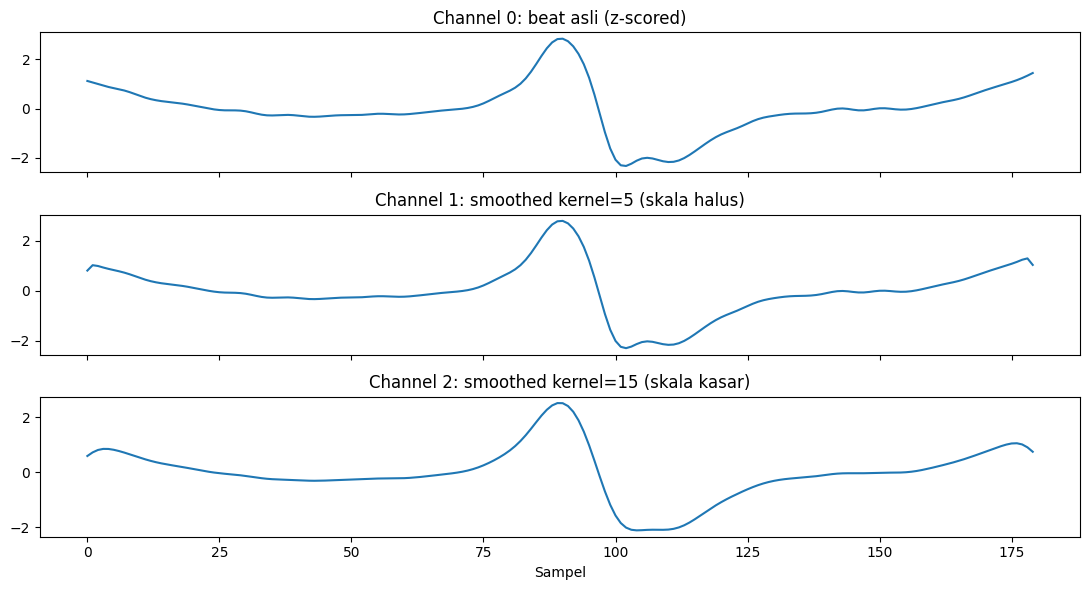

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
i = np.where(y_train_resampled == LABEL2IDX['V'])[0][0]   # contoh VEB
ax[0].plot(X_train_multi[i, :, 0]); ax[0].set_title('Channel 0: beat asli (z-scored)')
ax[1].plot(X_train_multi[i, :, 1]); ax[1].set_title(f'Channel 1: smoothed kernel={cfg.MS_KERNELS[0]} (skala halus)')
ax[2].plot(X_train_multi[i, :, 2]); ax[2].set_title(f'Channel 2: smoothed kernel={cfg.MS_KERNELS[1]} (skala kasar)')
ax[2].set_xlabel('Sampel'); plt.tight_layout(); plt.show()

## 14. Ringkasan handoff ke Arsya

File `processed/mitbih_ready.npz` berisi semua yang dibutuhkan model Hybrid CNN-Transformer:

| Key | Shape | Keterangan |
|-----|-------|-----------|
| `X_train` | (N', 180, 3) | beats train post-SMOTE, 3 channel multi-scale |
| `Xfeat_train` | (N', 13) | clinical features train post-SMOTE & scaling |
| `y_train` | (N',) | label 0-4 (N, S, V, F, Q) |
| `X_test` | (M, 180, 3) | beats test, **tidak** di-SMOTE |
| `Xfeat_test` | (M, 13) | clinical features test, **scaled pakai scaler train** |
| `y_test` | (M,) | label test |
| `groups_test` | (M,) | record ID per detak (untuk evaluasi per-pasien) |

**Cara load di pihak Arsya:**
```python
data = np.load('processed/mitbih_ready.npz')
X_train, Xf_train, y_train = data['X_train'], data['Xfeat_train'], data['y_train']
```

**Yang BELUM dikerjakan (Hari 8 ke atas):**
- Focal Loss (γ=2) — butuh integrasi dengan training loop Arsya
- Training loop + Adam + scheduler — butuh model jadi dulu
- Evaluasi MIT-BIH internal + Icentia11k eksternal

## 11. (Opsional) Simpan hasil ke Google Drive agar permanen
Sesi Colab terhapus saat idle. Jalankan ini bila ingin menyimpan `.npz` ke Drive.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# import shutil
# shutil.copy(out_path, '/content/drive/MyDrive/mitbih_interpatient.npz')
# print("Tersalin ke Google Drive.")

## 12. Peran Preprocessing

Jika tahapan filtering dan normalisasi (z-score) ini dilewati (langsung memotong sinyal mentah dan memasukkannya ke model AI), dampaknya akan sangat fatal terhadap performa model Anda.

**1. Model Belajar dari Pola Napas (Gagal Fokus)**

Saat EKG direkam, dada pasien pasti bergerak karena bernapas. Gerakan ini menghasilkan sinyal berfrekuensi sangat rendah (< 0.5 Hz) yang membuat keseluruhan grafik EKG tampak naik-turun seperti ombak besar. Ini disebut baseline wander.

Dampaknya: Jika lowcut filter (0.5 Hz) tidak diterapkan, model AI bisa jadi malah fokus mempelajari pola ombak pernapasan ini, alih-alih mempelajari bentuk gelombang jantungnya. AI akan kebingungan membedakan mana sinyal kelainan jantung dan mana sinyal tarikan napas.

**2. Model Tertipu oleh Listrik dan Getaran (False Alarm)**

Selain napas, ada noise berfrekuensi tinggi yang masuk ke alat perekam. Ini bisa berasal dari getaran otot pasien (menggigil/bergerak) atau interferensi listrik statis dari alat di sekitarnya (biasanya di frekuensi 50Hz atau 60Hz).

Dampaknya: Grafik EKG akan menjadi sangat bergerigi tajam. Tanpa highcut filter (45 Hz), model AI (terutama Deep Learning seperti CNN) bisa salah mengira gigi-gigi noise ini sebagai aritmia yang berbahaya (seperti fibrilasi), padahal itu cuma noise kabel atau otot.

**3. Menghafal Pasien, Bukan Menghafal Penyakit (Tanpa Z-Score)**

Setiap manusia memiliki anatomi dan ketebalan dada yang berbeda, sehingga tinggi amplitudo (voltase) EKG tiap pasien pasti berbeda-beda. Jantung yang sehat di Pasien A bisa saja tergambar lebih tinggi atau lebih pendek dari jantung sehat di Pasien B.

Dampaknya: Jika sinyal tidak diseragamkan amplitudonya dengan z-score, model AI tidak akan belajar ciri khas penyakitnya (morfologinya). Model malah akan menghafal: "Oh, kalau grafiknya tinggi, ini pasti datanya Pasien A". Akibatnya, saat model diuji ke pasien baru di dunia nyata, akurasinya akan hancur lebur (overfitting parah).

**4. Kesulitan Konvergensi (Gagal Belajar)**

Model neural network bekerja menggunakan kalkulasi matematika (gradien/turunan). Memasukkan angka mentah yang sangat acak, penuh noise, dan skalanya berantakan akan membuat perhitungan matematis di dalam model menjadi tidak stabil. Model akan membutuhkan waktu komputasi yang jauh lebih lama untuk belajar, atau bahkan gagal mengenali pola sama sekali.
